# EDA Inicial - Afiliados SNP

## Objetivo

- Realizar una primera exploración de dato
- conocer la estructura del dataset
- identificar los tipos de datos
- detectar valores faltantes
- realizar algunas graficos

## Importar Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time


CSV_PATH = Path("C:\\Users\\Leibnihtz\\Documents\\Leibtechs\\Docente_UNAJ\\2026-2\\BigData\\EDA\\data\\bronze\\Afiliados_SNP_Diciembre2025.csv")
inicio = time.perf_counter()
df = pd.read_csv(CSV_PATH)
tiempo_carga = time.perf_counter() - inicio

print(f"Tiempo de carga del archivo CSV: {tiempo_carga:.2f} segundos")

Tiempo de carga del archivo CSV: 12.02 segundos


In [3]:
df.head(10)

,id_persona,sexoact,fnacact,edadact,redadact,estcivil,dpto,aportante,tipo_afil,tipo_dep,tipo_trabajador,aporte,remuneracion,primer_periodo,ultimo_periodo,nro_aportes,monto_aportes
0,A0000000563730100,2,10/03/1965,60.0,5.0,2.0,25.0,1,1.0,1.0,21.0,161.589996,1243.00000,200002.0,202512.0,150,22092.990230
1,A0000001215562300,1,13/11/1985,40.0,3.0,NaN,15.0,0,1.0,1.0,21.0,127.209999,978.53845,202010.0,202011.0,2,260.200012
2,A0000003414490100,1,19/08/1966,59.0,5.0,1.0,17.0,0,1.0,1.0,20.0,141.589996,1089.15380,201504.0,201504.0,1,141.589996
3,A0000003825190100,2,29/05/1963,62.0,5.0,NaN,16.0,0,1.0,1.0,21.0,97.500000,750.00000,200901.0,201512.0,18,1651.000000
4,A0000004433070100,2,19/06/1956,69.0,6.0,1.0,25.0,0,1.0,1.0,20.0,82.279999,632.92310,201201.0,201202.0,2,129.449997
5,A0000007627200100,1,22/11/1969,56.0,5.0,2.0,25.0,0,1.0,1.0,21.0,66.300003,510.00003,200812.0,201202.0,10,1844.829956
6,A0000007897690100,1,09/06/1967,58.0,5.0,1.0,25.0,0,1.0,1.0,20.0,0.130000,1.00000,199907.0,201204.0,33,2050.639893
7,A0000008035020400,2,17/06/1952,73.0,6.0,NaN,16.0,0,1.0,1.0,21.0,53.299999,410.00000,200103.0,200106.0,4,213.199997
8,A0000008609920100,2,25/11/1968,57.0,5.0,2.0,25.0,0,1.0,1.0,21.0,107.250000,825.00000,200201.0,201206.0,125,10361.459960
9,A0000008673120400,1,27/04/1950,75.0,6.0,NaN,NaN,0,1.0,1.0,21.0,23.400000,180.00000,201108.0,201112.0,5,439.399994


In [4]:
df.shape

(4535229, 17)

In [5]:
memoria_mb= df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Uso de memoria del DataFrame: {memoria_mb:.2f} MB")

Uso de memoria del DataFrame: 1059.66 MB


In [6]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 4535229 entries, 0 to 4535228
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id_persona       str    
 1   sexoact          int64  
 2   fnacact          str    
 3   edadact          float64
 4   redadact         float64
 5   estcivil         float64
 6   dpto             float64
 7   aportante        int64  
 8   tipo_afil        float64
 9   tipo_dep         float64
 10  tipo_trabajador  float64
 11  aporte           float64
 12  remuneracion     float64
 13  primer_periodo   float64
 14  ultimo_periodo   float64
 15  nro_aportes      int64  
 16  monto_aportes    float64
dtypes: float64(12), int64(3), str(2)
memory usage: 1.0 GB


In [7]:
resumen = df.describe(include='all').transpose()
display(resumen)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_persona,4535229,4535229,A0000000563730100,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexoact,4535229.0,NaN,NaN,NaN,1.425072,0.494354,1.0,1.0,1.0,2.0,2.0
fnacact,4535144,28741,01/01/1992,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edadact,4535144.0,NaN,NaN,NaN,43.262117,13.368227,15.0,33.0,42.0,52.0,110.0
redadact,4535144.0,NaN,NaN,NaN,3.353869,1.32808,1.0,2.0,3.0,4.0,6.0
estcivil,2618161.0,NaN,NaN,NaN,1.193152,0.452657,1.0,1.0,1.0,1.0,4.0
dpto,4499398.0,NaN,NaN,NaN,12.454735,5.6679,1.0,8.0,15.0,15.0,25.0
aportante,4535229.0,NaN,NaN,NaN,0.311513,0.463112,0.0,0.0,0.0,1.0,1.0
tipo_afil,4508054.0,NaN,NaN,NaN,1.016408,0.127764,1.0,1.0,1.0,1.0,3.0
tipo_dep,4508054.0,NaN,NaN,NaN,1.016222,0.126329,1.0,1.0,1.0,1.0,2.0


In [8]:
nulos = pd.DataFrame({'cantidad':df.isna().sum(), 'porcentaje':df.isna().mean().mul(100).round(2)}).sort_values(by='cantidad', ascending=False)

In [9]:
display(nulos)

,cantidad,porcentaje
estcivil,1917068,42.27
aporte,335298,7.39
remuneracion,335298,7.39
tipo_trabajador,294616,6.50
monto_aportes,43190,0.95
dpto,35831,0.79
tipo_afil,27175,0.60
tipo_dep,27175,0.60
primer_periodo,385,0.01
ultimo_periodo,145,0.00


In [10]:
df.duplicated().sum()

np.int64(0)

In [18]:
columas_categoricas = ['sexoact','redadact']

for columna in columas_categoricas:
    print(f'{columna} ---')
    print(df[columna].value_counts(dropna=False).sort_index())

sexoact ---
sexoact
1    2607432
2    1927797
Name: count, dtype: int64
redadact ---
redadact
1.0     295147
2.0    1000362
3.0    1325263
4.0     947368
5.0     652876
6.0     314128
NaN         85
Name: count, dtype: int64


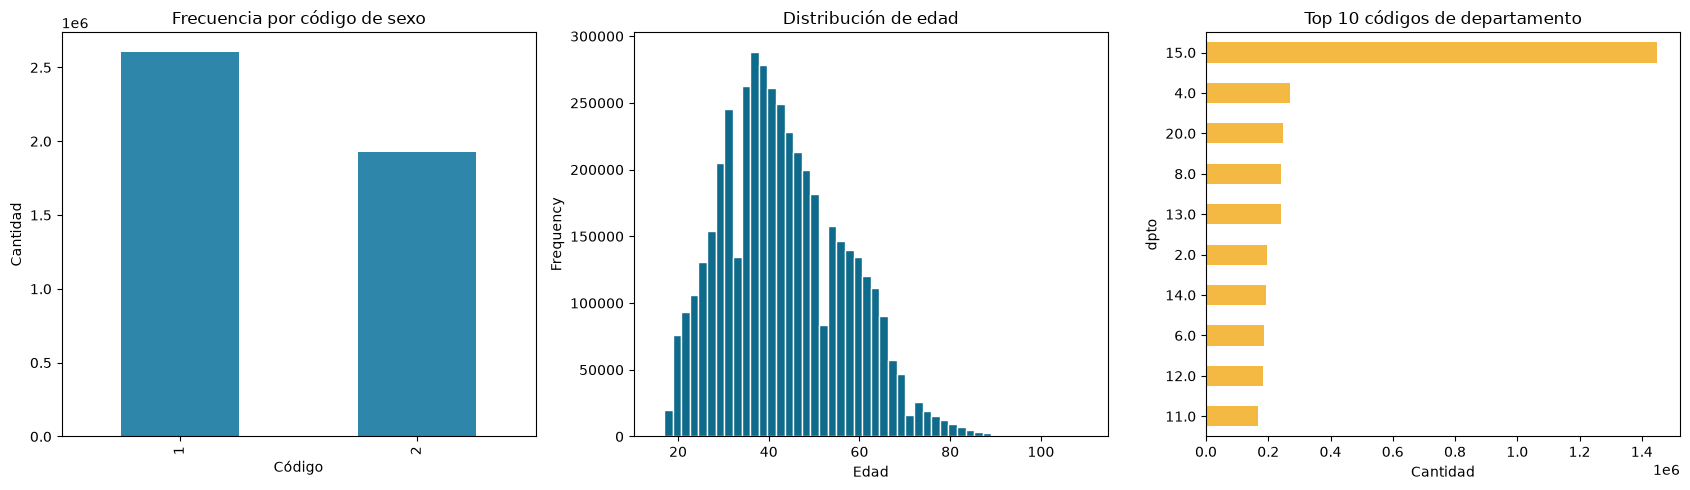

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

df['sexoact'].value_counts().sort_index().plot.bar(
    ax=axes[0], color='#2E86AB', title='Frecuencia por código de sexo'
)
axes[0].set_xlabel('Código')
axes[0].set_ylabel('Cantidad')

df['edadact'].dropna().plot.hist(
    bins=50, ax=axes[1], color='#0E6B8B', edgecolor='white',
    title='Distribución de edad'
)
axes[1].set_xlabel('Edad')

df['dpto'].value_counts().head(10).sort_values().plot.barh(
    ax=axes[2], color='#F4B942', title='Top 10 códigos de departamento'
)
axes[2].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()